# Extract Features from GAVD Datasets

## 1.  Setup

In [73]:
# Configure matplotlib FIRST before any other imports
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

# Verify matplotlib backend
print(f"Matplotlib backend: {matplotlib.get_backend()}")

# Enable interactive mode
plt.ion()

Matplotlib backend: module://matplotlib_inline.backend_inline


In [74]:
# Suppress TensorFlow and MediaPipe logs
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import sys
import string
import contextlib
import pandas as pd
import seaborn as sns
import numpy as np
from pathlib import Path
from collections import defaultdict

# Setup paths
project_root = Path.cwd().parent.parent
video_base_path = project_root / "data" / "youtube"
data_root = project_root / "experiments" / "exp3" / "data"

sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"Data root: {data_root}")
print(f"Video path: {video_base_path}")

Project root: c:\Users\alexm\projects\alex\alexpose
Data root: c:\Users\alexm\projects\alex\alexpose\experiments\exp3\data
Video path: c:\Users\alexm\projects\alex\alexpose\data\youtube


In [75]:
from ambient.gavd import GAVDDataLoader
from ambient.pose.keypoint_extractor import SequenceKeypointExtractor
from ambient.pose.joint_angles import get_joint_angles

from ambient.classification.knn_classifier import (
    KNNGaitClassifier,
    KNNClassifierConfig,
    GaitFeatureVector
)

print("✓ Imports successful")

✓ Imports successful


## 2. Explore Training Dataset

In [76]:
data_root

WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data')

In [79]:
# Get condition directories
condition_paths = [
    p for p in data_root.iterdir() 
    if p.is_dir() and p.name[0] in string.ascii_letters
]

len(condition_paths)

3

In [80]:

print(f"Found {len(condition_paths)} conditions:\n")
for path in sorted(condition_paths):
    csv_files = list(path.glob("*.csv"))
    print(f"  {path.name:15s}: {len(csv_files)} CSV files")

Found 3 conditions:

  normal         : 12 CSV files
  parkinsons     : 9 CSV files
  stroke         : 12 CSV files


## 3.  Extract Keypoints from One Gait (CSV) Sequence

In [81]:
normal_path = condition_paths[2]
stroke_path = condition_paths[0]
parkinsons_path = condition_paths[1]

normal_path, stroke_path, parkinsons_path

(WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/stroke'),
 WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/normal'),
 WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/parkinsons'))

In [139]:
# Let's get the first CSV from the normal_path
normal_csv = list(normal_path.glob("*.csv"))[11]
stroke_csv = list(stroke_path.glob("*.csv"))[0]
parkinsons_csv = list(parkinsons_path.glob("*.csv"))[3]
normal_csv, stroke_csv, parkinsons_csv

(WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/stroke/cljvvsucg00043n6l4evgn7q4.csv'),
 WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/normal/cljo2wwu7001a3n6ljmqm39l6.csv'),
 WindowsPath('c:/Users/alexm/projects/alex/alexpose/experiments/exp3/data/parkinsons/cljnz3l34000c3n6ldapq560j.csv'))

In [140]:
gavd_loader = GAVDDataLoader()

normal_df = gavd_loader.load_gavd_data(normal_csv)
stroke_df = gavd_loader.load_gavd_data(stroke_csv)
parkinsons_df = gavd_loader.load_gavd_data(parkinsons_csv)

normal_df.shape, stroke_df.shape, parkinsons_df.shape

2026-01-19 21:17:02.510 | INFO     | ambient.utils.youtube_cache:download_youtube_urls:310 - Downloading: https://www.youtube.com/watch?v=9VzOTO0nV8U


[youtube] Extracting URL: https://www.youtube.com/watch?v=9VzOTO0nV8U
[youtube] 9VzOTO0nV8U: Downloading webpage
[youtube] 9VzOTO0nV8U: Downloading android player API JSON


[info] 9VzOTO0nV8U: Downloading 1 format(s): 18
[download] Destination: C:\Users\alexm\projects\alex\alexpose\data\youtube\9VzOTO0nV8U.mp4
[download] 100% of    1.72MiB in 00:00:00 at 2.75MiB/s     
[Metadata] Adding metadata to "C:\Users\alexm\projects\alex\alexpose\data\youtube\9VzOTO0nV8U.mp4"


((166, 12), (96, 12), (170, 12))

In [141]:
normal_sid = normal_df.iloc[0]["seq"]
stroke_sid = stroke_df.iloc[0]["seq"]
parkinsons_sid = parkinsons_df.iloc[0]["seq"]

normal_sid, stroke_sid, parkinsons_sid

('cljvvsucg00043n6l4evgn7q4',
 'cljo2wwu7001a3n6ljmqm39l6',
 'cljnz3l34000c3n6ldapq560j')

In [142]:
video_base_path

WindowsPath('c:/Users/alexm/projects/alex/alexpose/data/youtube')

In [92]:
extractor = SequenceKeypointExtractor()
normal_keypoints_array = extractor.extract_from_sequence(
    sequence_data=normal_df,
    video_base_path=video_base_path
)
stroke_keypoints_array = extractor.extract_from_sequence(
    sequence_data=stroke_df,
    video_base_path=video_base_path
)
parkinsons_keypoints_array = extractor.extract_from_sequence(
    sequence_data=parkinsons_df,
    video_base_path=video_base_path
)
len(normal_keypoints_array), len(stroke_keypoints_array), len(parkinsons_keypoints_array)

(82, 96, 170)

In [144]:
len(normal_keypoints_array[9].keypoints), len(stroke_keypoints_array[0].keypoints), len(parkinsons_keypoints_array[0].keypoints)

(33, 33, 33)

In [145]:
# let's look at the first keypoint at frame 0
normal_keypoints_array[0].keypoints[0]

Keypoint(id=0, name='NOSE', x=310.0192642211914, y=68.62894177436829, z=-0.27365198731422424, confidence=0.9999957084655762, visibility=0.9999957084655762, presence=0.9999676942825317, x_normalized=0.4844051003456116, y_normalized=0.19063594937324524)

In [146]:
from pprint import pprint

print(vars(normal_keypoints_array[0].keypoints[0]))

{'id': 0, 'name': 'NOSE', 'x': 310.0192642211914, 'y': 68.62894177436829, 'z': -0.27365198731422424, 'confidence': 0.9999957084655762, 'visibility': 0.9999957084655762, 'presence': 0.9999676942825317, 'x_normalized': 0.4844051003456116, 'y_normalized': 0.19063594937324524}


## 4.  Calculate Frame-by-Frame Joint Angles

In [147]:
normal_joint_angles = get_joint_angles(
    keypoints_array=normal_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=sequence_id
)
stroke_joint_angles = get_joint_angles(
    keypoints_array=stroke_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=sequence_id
)
parkinsons_joint_angles = get_joint_angles(
    keypoints_array=parkinsons_keypoints_array,
    keypoint_format="BLAZEPOSE_33",
    fps=30.0,
    confidence_threshold=0.3,
    sequence_id=sequence_id
)

# let's see which joint angles are calculated for Frame 0 (same for all other frames)
print(normal_joint_angles.frames[0].angles.keys())

dict_keys(['left_hip', 'left_knee', 'right_hip', 'right_knee', 'left_ankle', 'right_ankle'])


In [148]:
print("Normal Gait: Left Hip")
normal_joint_angles.get_statistics("left_hip")

Normal Gait: Left Hip


{'mean': 171.4004995963799,
 'std': 2.1993556310501794,
 'min': 167.21518001619688,
 'max': 175.92757143676488,
 'range': 8.712391420567997,
 'valid_count': 166}

In [149]:
print("Stroke Gait: Left Hip")
stroke_joint_angles.get_statistics("left_hip")


Stroke Gait: Left Hip


{'mean': 170.43671395722,
 'std': 4.295789252078132,
 'min': 159.02212612884645,
 'max': 179.81153701123407,
 'range': 20.789410882387614,
 'valid_count': 96}

In [150]:
print("Parkinsons Gait: Left Hip")
parkinsons_joint_angles.get_statistics("left_hip")

Parkinsons Gait: Left Hip


{'mean': 174.36503800176894,
 'std': 3.192786188339347,
 'min': 164.54183931275827,
 'max': 179.85488425284845,
 'range': 15.31304494009018,
 'valid_count': 170}

Let's visualize the joint angle changes over a gait sequence

In [125]:
import matplotlib.pyplot as plt

def plot_joint_angles_statistics(name, joint_angles):

    print(f"\nVisualizing joint angles for {name}...")
    print(f"Number of frames with joint angles: {len(joint_angles.frames)}")

    if len(joint_angles.frames) > 0 and len(joint_angles.frames[0].angles) > 0:
        joints = ['left_hip', 'left_knee', 'left_ankle', 'right_hip', 'right_knee', 'right_ankle']
        
        # Create the figure
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"{name} Joint Angles Over Time - {normal_path.name}", fontsize=18, fontweight='bold')
        
        for idx, joint_name in enumerate(joints):
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            try:
                # Get angle data
                angles = joint_angles.get_joint_angle_series(joint_name)
                stats = joint_angles.get_statistics(joint_name)
                
                # Check if we have valid data
                if stats['valid_count'] > 0 and not np.isnan(stats['mean']):
                    # Filter out NaN values
                    valid_mask = ~np.isnan(angles)
                    valid_frames = np.where(valid_mask)[0]
                    valid_angles = angles[valid_mask]
                    
                    if len(valid_angles) > 0:
                        # Plot the angle series
                        ax.plot(valid_frames, valid_angles, 'b-', linewidth=2, alpha=0.7, label='Angle')
                        
                        # Add mean line
                        ax.axhline(y=stats['mean'], color='red', linestyle='--', 
                                linewidth=2, alpha=0.8, label=f"Mean: {stats['mean']:.1f}°")
                        
                        # Add shaded region for std
                        ax.axhspan(stats['mean'] - stats['std'], stats['mean'] + stats['std'], 
                                alpha=0.2, color='red', label=f"±1 SD")
                        
                        # Formatting
                        ax.set_title(joint_name.replace('_', ' ').title(), 
                                    fontsize=13, fontweight='bold', pad=10)
                        ax.set_xlabel('Frame Number', fontsize=11)
                        ax.set_ylabel('Angle (degrees)', fontsize=11)
                        ax.legend(loc='best', fontsize=9, framealpha=0.9)
                        ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
                        
                        # Set reasonable y-axis limits
                        y_margin = (stats['max'] - stats['min']) * 0.1
                        ax.set_ylim(stats['min'] - y_margin, stats['max'] + y_margin)
                    else:
                        ax.text(0.5, 0.5, 'No valid angle data', 
                            ha='center', va='center', transform=ax.transAxes, 
                            fontsize=12, color='gray')
                        ax.set_title(joint_name.replace('_', ' ').title())
                else:
                    ax.text(0.5, 0.5, 'Insufficient data', 
                        ha='center', va='center', transform=ax.transAxes, 
                        fontsize=12, color='gray')
                    ax.set_title(joint_name.replace('_', ' ').title())
                    
            except Exception as e:
                ax.text(0.5, 0.5, f'Error: {str(e)[:40]}', 
                    ha='center', va='center', transform=ax.transAxes, 
                    fontsize=10, color='red', wrap=True)
                ax.set_title(joint_name.replace('_', ' ').title())
                print(f"Error plotting {joint_name}: {e}")
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        
        # Print statistics table
        print("\n" + "="*70)
        print("Joint Angle Statistics")
        print("="*70)
        print(f"{'Joint':<15} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8} {'Range':>8}")
        print("-"*70)
        
        for joint_name in joints:
            try:
                stats = joint_angles.get_statistics(joint_name)
                if stats['valid_count'] > 0:
                    print(f"{joint_name:<15} {stats['mean']:>8.1f}° {stats['std']:>7.1f}° "
                        f"{stats['min']:>7.1f}° {stats['max']:>7.1f}° {stats['range']:>7.1f}°")
                else:
                    print(f"{joint_name:<15} {'No data':>8}")
            except Exception as e:
                print(f"{joint_name:<15} Error: {e}")
        print("="*70 + "\n")
        
    else:
        print("\n⚠️  WARNING: No joint angles computed!")
        print(f"   Total frames: {len(joint_angles.frames)}")
        if len(joint_angles.frames) > 0:
            print(f"   Angles in first frame: {len(joint_angles.frames[0].angles)}")
            print(f"   Available joints: {list(joint_angles.frames[0].angles.keys())}")
        print("   Check if keypoints were extracted successfully.\n")


Visualizing joint angles for Normal Gait...
Number of frames with joint angles: 166


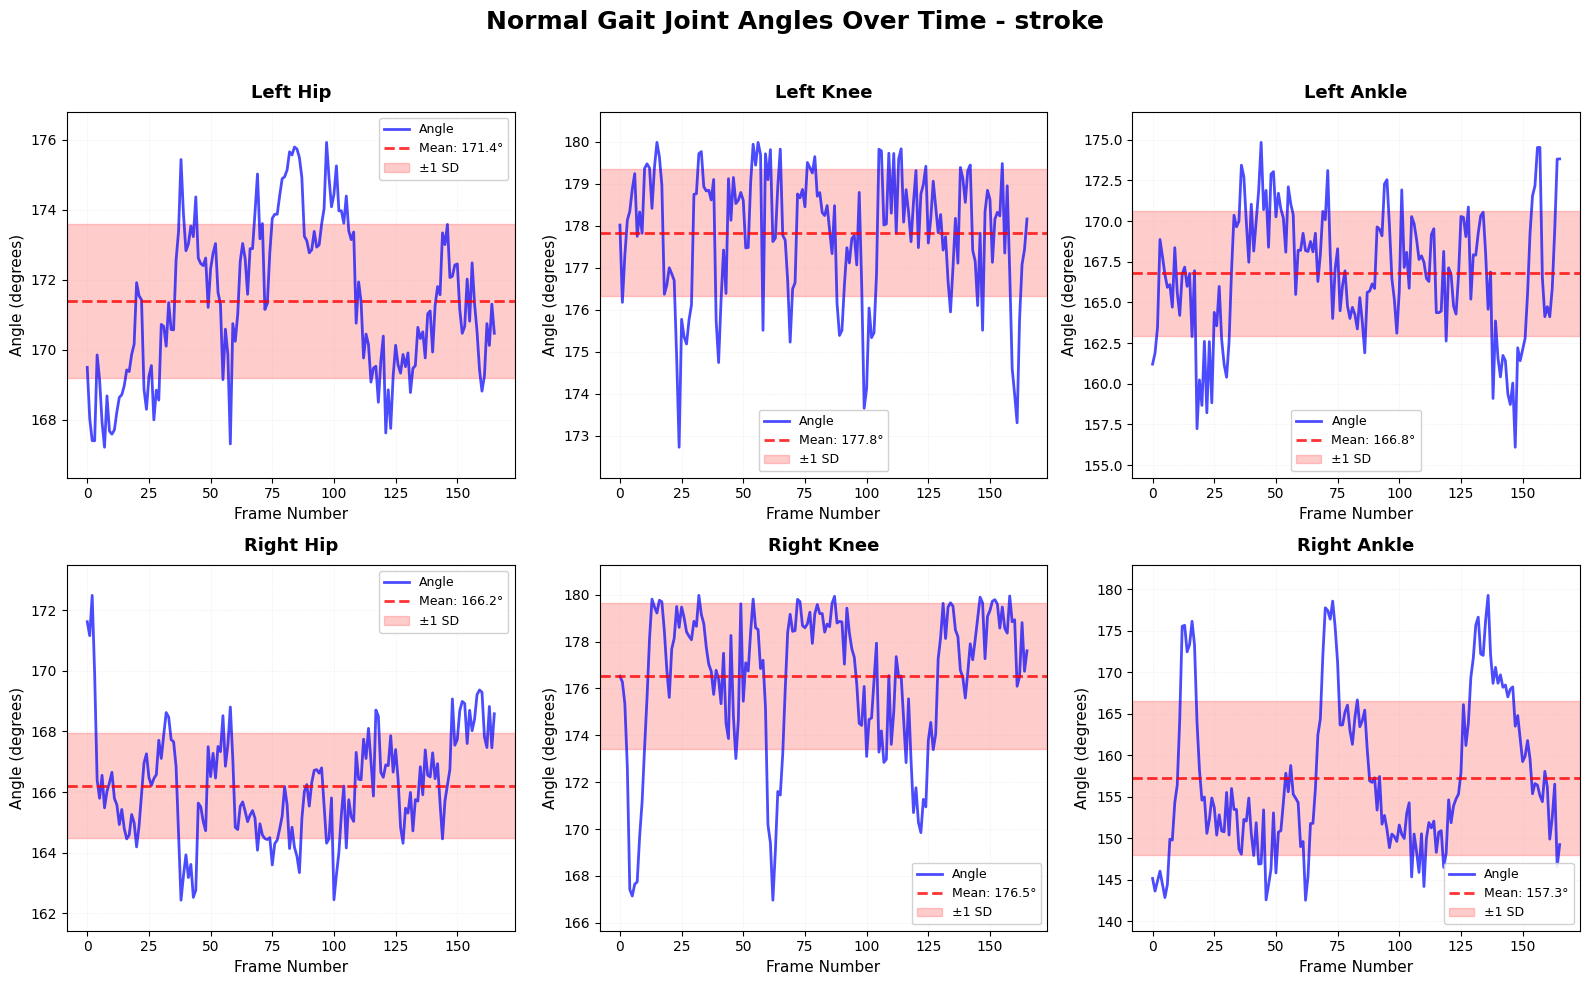


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           171.4°     2.2°   167.2°   175.9°     8.7°
left_knee          177.8°     1.5°   172.7°   180.0°     7.3°
left_ankle         166.8°     3.8°   156.1°   174.8°    18.7°
right_hip          166.2°     1.7°   162.4°   172.5°    10.1°
right_knee         176.5°     3.1°   167.0°   180.0°    13.0°
right_ankle        157.3°     9.3°   142.5°   179.3°    36.8°



In [151]:
plot_joint_angles_statistics("Normal Gait", normal_joint_angles)


Visualizing joint angles for Stroke Gait...
Number of frames with joint angles: 96


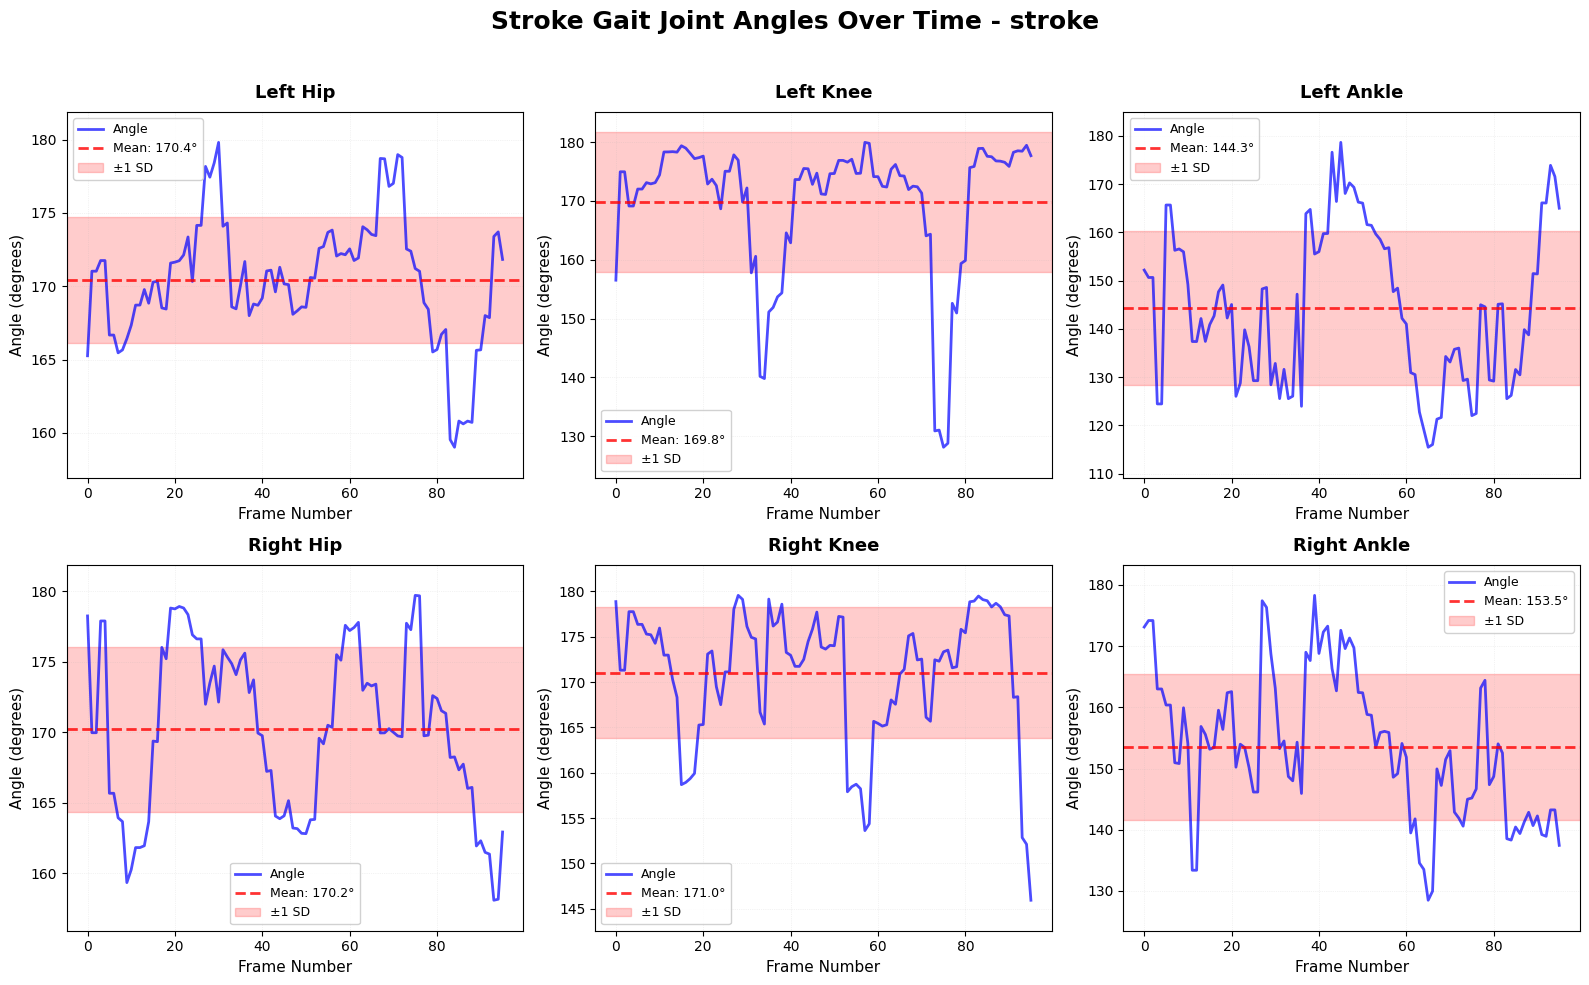


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           170.4°     4.3°   159.0°   179.8°    20.8°
left_knee          169.8°    11.9°   128.1°   180.0°    51.8°
left_ankle         144.3°    16.0°   115.5°   178.7°    63.2°
right_hip          170.2°     5.8°   158.1°   179.7°    21.6°
right_knee         171.0°     7.2°   145.9°   179.6°    33.6°
right_ankle        153.5°    11.9°   128.5°   178.3°    49.8°



In [152]:
plot_joint_angles_statistics("Stroke Gait", stroke_joint_angles)


Visualizing joint angles for Parkinsons Gait...
Number of frames with joint angles: 170


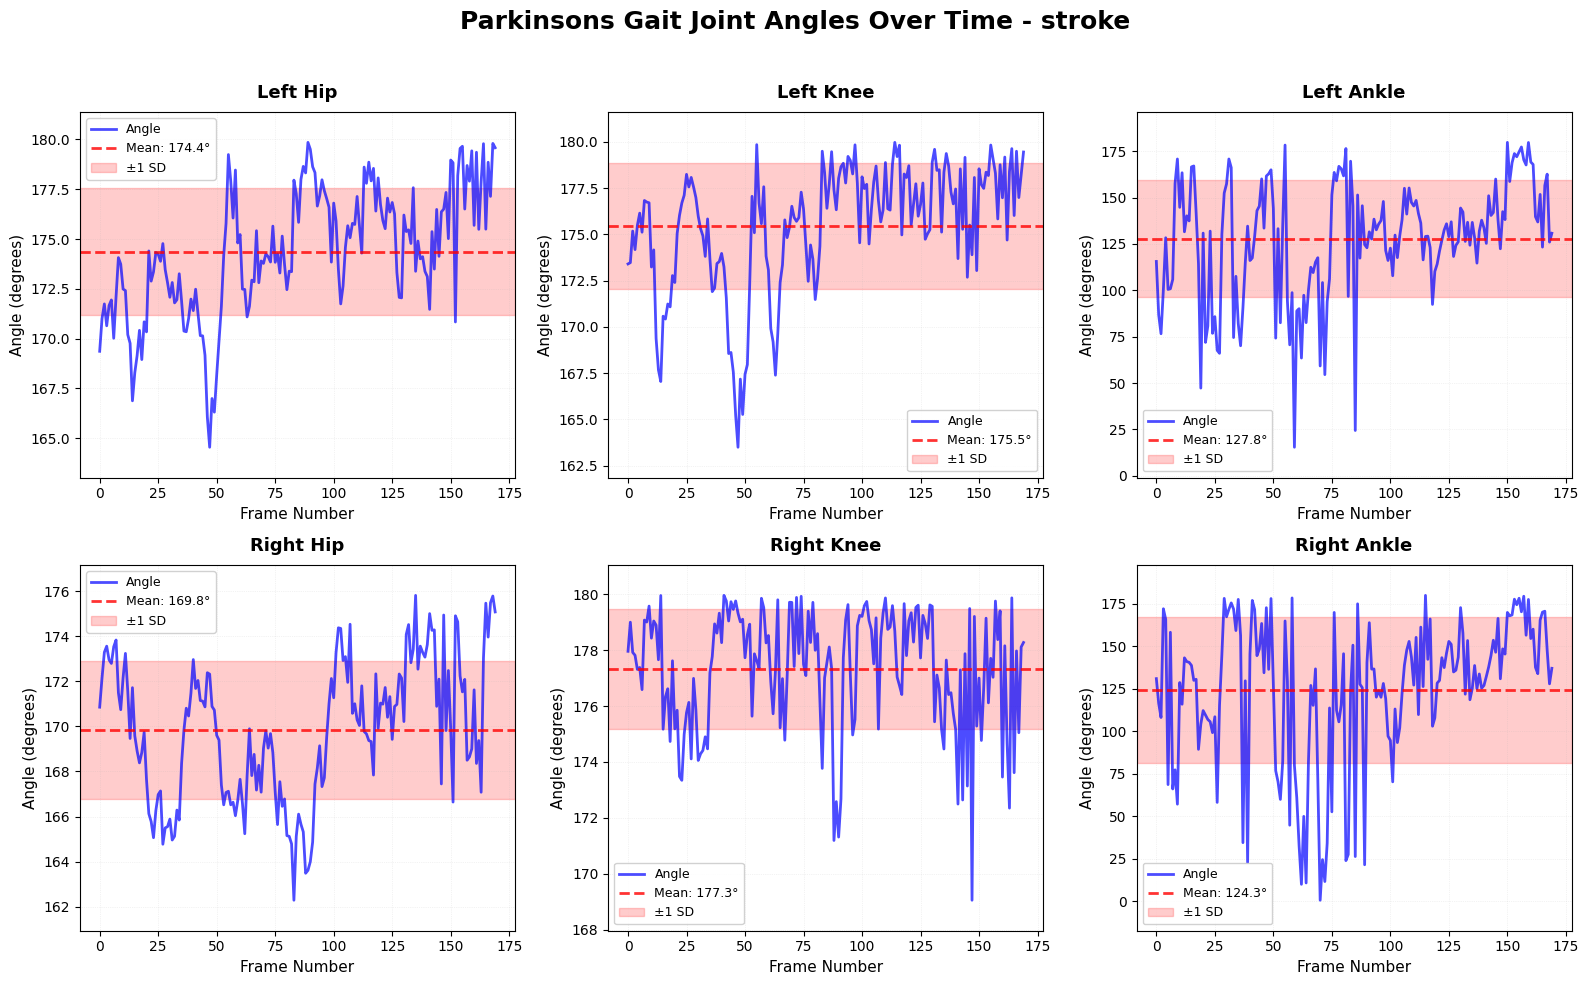


Joint Angle Statistics
Joint               Mean      Std      Min      Max    Range
----------------------------------------------------------------------
left_hip           174.4°     3.2°   164.5°   179.9°    15.3°
left_knee          175.5°     3.4°   163.5°   180.0°    16.5°
left_ankle         127.8°    31.6°    15.4°   179.7°   164.3°
right_hip          169.8°     3.1°   162.3°   175.8°    13.5°
right_knee         177.3°     2.2°   169.1°   180.0°    10.9°
right_ankle        124.3°    42.8°     0.5°   180.0°   179.4°



In [153]:
plot_joint_angles_statistics("Parkinsons Gait", parkinsons_joint_angles)